In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 103M/103M [00:00<00:00, 136MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1


In [2]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Correctly identify the base path for the dataset content
dataset_base_path = os.path.join(path, 'Car-Bike-Dataset')

# Check if 'Car-Bike-Dataset' exists and list its contents
if os.path.exists(dataset_base_path):
    print(f"\nContents of the '{os.path.basename(dataset_base_path)}' directory ({dataset_base_path}):\n{os.listdir(dataset_base_path)}")
    # Further checks can be added here if needed, e.g., for 'Train' and 'Test' subdirectories
else:
    print(f"\n'Car-Bike-Dataset' directory not found at {dataset_base_path}. Please verify the dataset structure.")


Contents of the dataset directory (/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1):
['Car-Bike-Dataset']

Contents of the 'Car-Bike-Dataset' directory (/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset):
['Car', 'Bike']


In [3]:
import os
from sklearn.model_selection import train_test_split

# Define the base path to the dataset, which was identified in the previous cell
# dataset_base_path is '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset'

# Initialize lists to store image paths and labels
all_image_paths = []
all_image_labels = []

# Iterate through each category (Car, Bike)
for category in ['Car', 'Bike']:
    category_path = os.path.join(dataset_base_path, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(category_path, img_name))
            all_image_labels.append(category)

print(f"Total images found: {len(all_image_paths)}")
print(f"Example image path: {all_image_paths[0] if all_image_paths else 'N/A'}")
print(f"Example image label: {all_image_labels[0] if all_image_labels else 'N/A'}")

Total images found: 3996
Example image path: /root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset/Car/Car (936).jpeg
Example image label: Car


In [4]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, random_state=42, stratify=all_image_labels
)

print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print("Dataset split successfully!")

Number of training images: 3196
Number of testing images: 800
Dataset split successfully!


## Check GPU Availability

In [5]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} device(s)")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled for GPUs.")
else:
    print("No GPU devices found. Training will run on CPU.")

GPU available: 1 device(s)
Memory growth enabled for GPUs.


## Prepare Data for VGG Model

To use `ImageDataGenerator.flow_from_dataframe`, we need to convert our lists of image paths and labels into pandas DataFrames.

In [6]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create DataFrames for training and testing
train_df = pd.DataFrame({'filename': X_train, 'class': y_train})
test_df = pd.DataFrame({'filename': X_test, 'class': y_test})

# Define image dimensions
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocessing for validation/test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for evaluation
)

Found 3196 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.


## Build and Compile the VGG Model

We'll use a pre-trained VGG16 model as a base and add custom classification layers on top.

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load the VGG16 model without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of VGG16
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train the VGG Model

In [8]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/10
 61/100 ━━━━━━━━━━━━━━━━━━━━ 25s 657ms/step - accuracy: 0.7654 - loss: 0.4972

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 644ms/step - accuracy: 0.9030 - loss: 0.2268 - val_accuracy: 0.9737 - val_loss: 0.0667
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 514ms/step - accuracy: 0.9556 - loss: 0.1155 - val_accuracy: 0.9825 - val_loss: 0.0572
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 520ms/step - accuracy: 0.9528 - loss: 0.1067 - val_accuracy: 0.9837 - val_loss: 0.0503
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 529ms/step - accuracy: 0.9587 - loss: 0.1082 - val_accuracy: 0.9837 - val_loss: 0.0429
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 513ms/step - accuracy: 0.9571 - loss: 0.1010 - val_accuracy: 0.9862 - val_loss: 0.0436
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 518ms/step - accuracy: 0.9656 - loss: 0.0885 - val_accuracy: 0.9850 - val_loss: 0.0460
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 525ms/step - accuracy: 0.9687 - loss: 0.0802 - val_accuracy: 0.9850 - val_loss: 0.0466
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 522ms/step - accuracy: 0.9718 - loss: 0.0782 - val

## Summarize Training Results

In [9]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Loss: 0.0403
Test Accuracy: 98.37%


## Display Training History Plots

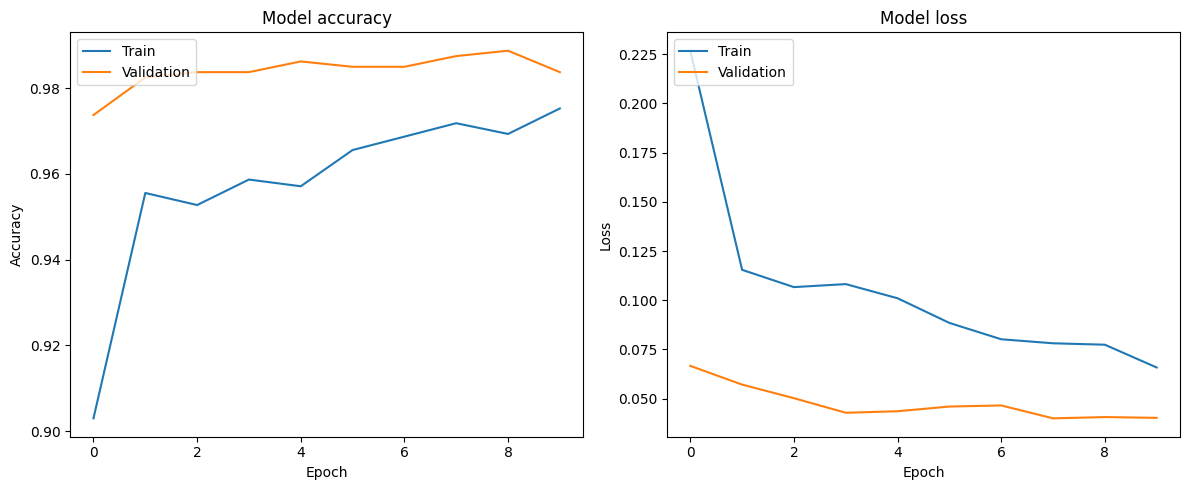

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()